In [1]:
# Imports
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Radar, PyPizza, FontManager, grid
%matplotlib inline

In [2]:
# Open And Read Data File
with open ('kelleher_pen_saves.csv', 'r')as f:
    
# Create Variable For The Reader Object, Use *csv.reader* Calling The File Name  
    csv_reader = csv.reader(f)
    
# Use For Loop To Get Each Row Of The File
    for row in csv_reader:
        
# Use Print Function, Printing Each *row* To Show Data
        print(row)

['Player', 'Team ', 'League', 'Fixture ', 'Pen Attmpt', 'Saved']
['Kelleher', 'Liverpool ', 'Champions League', '(A) Midtjylland (20/21)', '1', '0']
['Kelleher', 'Liverpool ', 'EFL Cup', '(A) Norwich (21/22)', '1', '1']
['Kelleher', 'Northern Ireland', 'UEFA Nations League', '(H) Finland (24/25)', '1', '1']
['Kelleher', 'Northan Ireland', 'UEFA Nations League', '(A) England (24/25)', '1', '0']
['Kelleher', 'Liverpool ', 'Premier League', '(H) Southampton  (24/25)', '1', '1']
['Kelleher', 'Liverpool ', 'Champions League', '(H) Real Madrid  (24/25)', '1', '1']


In [3]:
# Store File In Variable, Read File
pen_stats = pd.read_csv('kelleher_pen_saves.csv')

# Show Df
pen_stats

,Player,Team,League,Fixture,Pen Attmpt,Saved
0,Kelleher,Liverpool,Champions League,(A) Midtjylland (20/21),1,0
1,Kelleher,Liverpool,EFL Cup,(A) Norwich (21/22),1,1
2,Kelleher,Northern Ireland,UEFA Nations League,(H) Finland (24/25),1,1
3,Kelleher,Northan Ireland,UEFA Nations League,(A) England (24/25),1,0
4,Kelleher,Liverpool,Premier League,(H) Southampton (24/25),1,1
5,Kelleher,Liverpool,Champions League,(H) Real Madrid (24/25),1,1


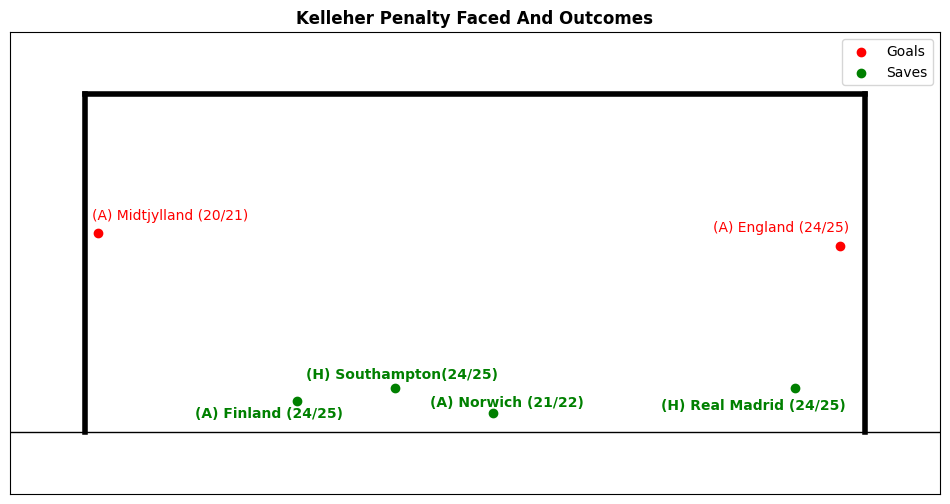

In [4]:
# Define Goal Dimensions
width = 10.32
height = 5.44

# Create Figure & Axis
fig, ax = plt.subplots(figsize=(12, 6))

# Draw Goal As Three Separate Lines (top, left, right)
goal_lines = [
    plt.Line2D([0, width], [height, height], color='black', lw=4),  # Top line
    plt.Line2D([0, 0], [0, height], color='black', lw=4),  # Left line
    plt.Line2D([width, width], [0, height], color='black', lw=4)  # Right line
]

# Use For Loop To Add Goal Lines. 
for line in goal_lines:
    ax.add_line(line)

# Add Ground Line Stretching Across Width Of Graph
# Horizontal Line At y=0
ax.axhline(0, color='black', lw=1)  


# Plots Goals
goals = [(0.16, 3.2), (10, 3)]  
# Labels For Goals
goal_labels = ['(A) Midtjylland (20/21)','(A) England (24/25)']  

# Plots Misses
saves = [(5.4, 0.3), (2.8, 0.5), (4.1, 0.7), (9.4, 0.7)]
# Labels For Misses
saves_labels = ['(A) Norwich (21/22)','(A) Finland (24/25)','(H) Southampton(24/25)','(H) Real Madrid (24/25)'] 

# Plot Goals & Misses
goal_scatter = ax.scatter(*zip(*goals), color='red', label='Goals', zorder=2)
saves_scatter = ax.scatter(*zip(*saves), color='green', label='Saves', zorder=4)

# Custom Offsets For Goal Label
goal_offsets = [(52, 10), (-43, 10)]

# Annotate Each Point With Separate Offsets
# *for* Loop *in zip* (point *goals*, label *goal_labels*, offset *goal_offsets*)
for point, label, offset in zip(goals, goal_labels, goal_offsets):
    # Annotate ax - (*label*, 
    # Index Points *point[] point[]*,- 
    # Use 'offset points' For *textcoords*, offset *xytext*, 
    # Center *ha*,
    # Choose *fontsize*,
    # Choose *color*)
    ax.annotate(label, 
                (point[0], point[1]), 
                textcoords="offset points", 
                xytext=offset, 
                ha='center', 
                fontsize=10, 
                color='red')

# Custom Offsets For Save/Miss Label
save_offsets = [(10, 5), (-20, -12), (5,7), (-30,-15)]
# For Loop To Get Data
for point, label, offset in zip(saves, saves_labels, save_offsets):
    # Annotate Each Point With Separate Offsets
    ax.annotate(label, 
                (point[0], point[1]), 
                textcoords="offset points", 
                xytext=offset, 
                ha='center', 
                fontsize=10, 
                color='green',
               fontweight = 'bold')
             
# Set Axis Limits & Remove Ticks
ax.set_xlim(-1, width + 1)
ax.set_ylim(-1, height + 1)

# Remove x-axis Ticks
ax.set_xticks([]) 
# Remove y-axis Ticks
ax.set_yticks([]) 

# Set Title And Style
ax.set_title('Kelleher Penalty Faced And Outcomes', fontweight = 'bold')

# Plot Legend
ax.legend()

# Display Figure
plt.show()

In [5]:
# Open And Read Data File
with open ('kelleher_stats.csv', 'r') as  f:
# Create Variable For The Reader Object, Use *csv.reader* Calling The File Name        
    csv_reader = csv.reader(f)
# Use For Loop To Get Each Row Of The File
    for row in csv_reader:
# Use Print Function, Printing Each *row* To Show Data
        print(row)

['Competiton', 'Fixture', 'SoTA', 'GA', 'Saves', 'Save %', 'PSxG', 'Launched %', 'Pass', 'Throw', 'Avg Length', 'G.K Avg Length']
['English Premier League', 'Newcastle (A)', '6', '3', '3', '50.00%', '2.5', '27.30%', '42', '9', '25.5', '40.7']
['English Premier League', 'Manchester City H)', '2', '0', '2', '100.00%', '0.9', '18.80%', '45', '5', '31.6', '0']
['Uefa Champions League', 'Real Madrid (H)', '3', '0', '2', '100.00%', '1.8', '50.00%', '28', '3', '21.7', '19.4']
['English Premier League', 'Southampton (A)', '5', '2', '2', '60.00%', '1.7', '28.60%', '17', '1', '29.9', '44.7']
['English Premier League', 'Aston Villa (H)', '2', '0', '2', '100.00%', '0.6', '16.70%', '28', '3', '25.7', '62']
['Uefa Champions League', 'Bayer Levekusen (H)', '4', '0', '4', '100.00%', '0.7', '36.40%', '31', '2', '32.7', '37.8']
['English Premier League', 'Brighton (H)', '5', '1', '4', '80.00%', '0.5', '25.00%', '27', '4', '25.4', '0']
['English Premier League', 'Arsenal (A)', '3', '2', '1', '33.30%', '1

In [6]:
# Read csv File
keeper_stats= pd.read_csv('kelleher_stats.csv')
# Show Df
keeper_stats

,Competiton,Fixture,SoTA,GA,Saves,Save %,PSxG,Launched %,Pass,Throw,Avg Length,G.K Avg Length
0,English Premier League,Newcastle (A),6,3,3,50.00%,2.5,27.30%,42,9,25.5,40.7
1,English Premier League,Manchester City H),2,0,2,100.00%,0.9,18.80%,45,5,31.6,0.0
2,Uefa Champions League,Real Madrid (H),3,0,2,100.00%,1.8,50.00%,28,3,21.7,19.4
3,English Premier League,Southampton (A),5,2,2,60.00%,1.7,28.60%,17,1,29.9,44.7
4,English Premier League,Aston Villa (H),2,0,2,100.00%,0.6,16.70%,28,3,25.7,62.0
5,Uefa Champions League,Bayer Levekusen (H),4,0,4,100.00%,0.7,36.40%,31,2,32.7,37.8
6,English Premier League,Brighton (H),5,1,4,80.00%,0.5,25.00%,27,4,25.4,0.0
7,English Premier League,Arsenal (A),3,2,1,33.30%,1.7,33.30%,41,3,37.0,35.0
8,Uefa Champions League,RB Leipzig (A),6,0,6,100.00%,1.2,36.40%,38,2,29.0,36.5
9,English Premier League,Chelsea (H),2,1,1,50.00%,0.9,20.00%,37,4,35.9,41.0


### Saves & %

In [7]:
# Show Df
keeper_stats

,Competiton,Fixture,SoTA,GA,Saves,Save %,PSxG,Launched %,Pass,Throw,Avg Length,G.K Avg Length
0,English Premier League,Newcastle (A),6,3,3,50.00%,2.5,27.30%,42,9,25.5,40.7
1,English Premier League,Manchester City H),2,0,2,100.00%,0.9,18.80%,45,5,31.6,0.0
2,Uefa Champions League,Real Madrid (H),3,0,2,100.00%,1.8,50.00%,28,3,21.7,19.4
3,English Premier League,Southampton (A),5,2,2,60.00%,1.7,28.60%,17,1,29.9,44.7
4,English Premier League,Aston Villa (H),2,0,2,100.00%,0.6,16.70%,28,3,25.7,62.0
5,Uefa Champions League,Bayer Levekusen (H),4,0,4,100.00%,0.7,36.40%,31,2,32.7,37.8
6,English Premier League,Brighton (H),5,1,4,80.00%,0.5,25.00%,27,4,25.4,0.0
7,English Premier League,Arsenal (A),3,2,1,33.30%,1.7,33.30%,41,3,37.0,35.0
8,Uefa Champions League,RB Leipzig (A),6,0,6,100.00%,1.2,36.40%,38,2,29.0,36.5
9,English Premier League,Chelsea (H),2,1,1,50.00%,0.9,20.00%,37,4,35.9,41.0


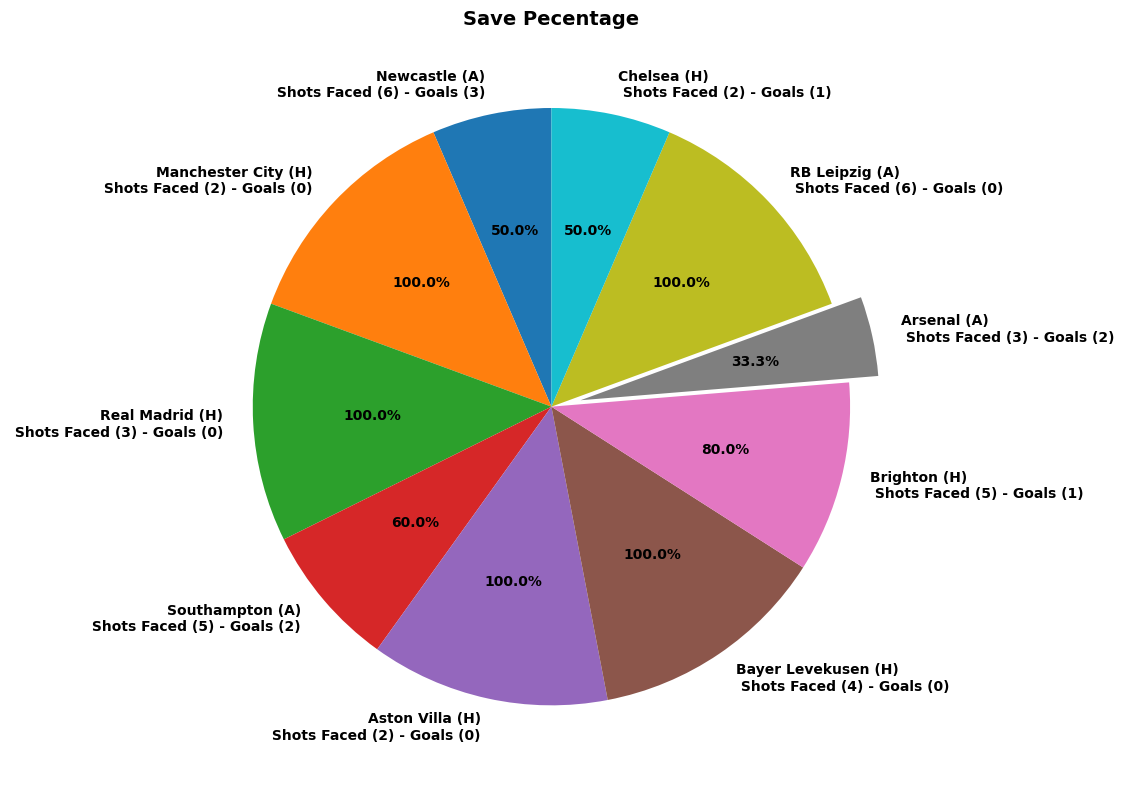

In [12]:
# Create List Of Fixtures
fixtures = [
    "Newcastle (A)\n Shots Faced (6) - Goals (3)","Manchester City (H)\n Shots Faced (2) - Goals (0)",
    "Real Madrid (H)\n Shots Faced (3) - Goals (0)", "Southampton (A)\n Shots Faced (5) - Goals (2)",
    "Aston Villa (H)\n Shots Faced (2) - Goals (0)","Bayer Levekusen (H)\n Shots Faced (4) - Goals (0)",
    "Brighton (H)\n Shots Faced (5) - Goals (1)", "Arsenal (A)\n Shots Faced (3) - Goals (2)",
    "RB Leipzig (A)\n Shots Faced (6) - Goals (0)","Chelsea (H)\n Shots Faced (2) - Goals (1)"
]

# Create List Of Values 
values = [50, 100, 100, 60, 100, 100, 80, 33.3, 100, 50]

# Create Pie Chart
# Plot Figure & Size
    # Call :
        #  Wedges = Manipulate Wedge (explode)
        #  Texts = (For)Loop Through To Modify Outside Labels (size, style, color)
        #  Autotexts = (For)Loop Through To Modify Inside Labels (size, style, color)
        #  Plot Pie (
                # values - List Of Values Creates,
                # labels = - List Of Fixtures ,
                # ? explode = - Raise 'Slice' Above Rest ?,
                # autopct = - Use *lambda* And *f-string* To Show Percetnage. - lambda '': f'{'' * sum(values) / 100.:1f}%',
                # startangle = Rotates Pie Chart,
                # textprops = {'fontsize' :} Styles Texts
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    values,
    labels=fixtures,
    explode=[0,0,0,0,0,0,0,0.1,0,0],
    autopct=lambda p: f'{p * sum(values) / 100:.1f}%',  
    startangle=90,
    textprops={'fontsize': 10, 'weight':'bold'}
)

# Plot Title
plt.title("Save Pecentage", fontsize=14, fontweight='bold')

# Adjust Spacing For Graph
plt.tight_layout()

# Display Figure
plt.show()

#### SOTA & GA

In [13]:
# Show Df
keeper_stats

,Competiton,Fixture,SoTA,GA,Saves,Save %,PSxG,Launched %,Pass,Throw,Avg Length,G.K Avg Length
0,English Premier League,Newcastle (A),6,3,3,50.00%,2.5,27.30%,42,9,25.5,40.7
1,English Premier League,Manchester City H),2,0,2,100.00%,0.9,18.80%,45,5,31.6,0.0
2,Uefa Champions League,Real Madrid (H),3,0,2,100.00%,1.8,50.00%,28,3,21.7,19.4
3,English Premier League,Southampton (A),5,2,2,60.00%,1.7,28.60%,17,1,29.9,44.7
4,English Premier League,Aston Villa (H),2,0,2,100.00%,0.6,16.70%,28,3,25.7,62.0
5,Uefa Champions League,Bayer Levekusen (H),4,0,4,100.00%,0.7,36.40%,31,2,32.7,37.8
6,English Premier League,Brighton (H),5,1,4,80.00%,0.5,25.00%,27,4,25.4,0.0
7,English Premier League,Arsenal (A),3,2,1,33.30%,1.7,33.30%,41,3,37.0,35.0
8,Uefa Champions League,RB Leipzig (A),6,0,6,100.00%,1.2,36.40%,38,2,29.0,36.5
9,English Premier League,Chelsea (H),2,1,1,50.00%,0.9,20.00%,37,4,35.9,41.0


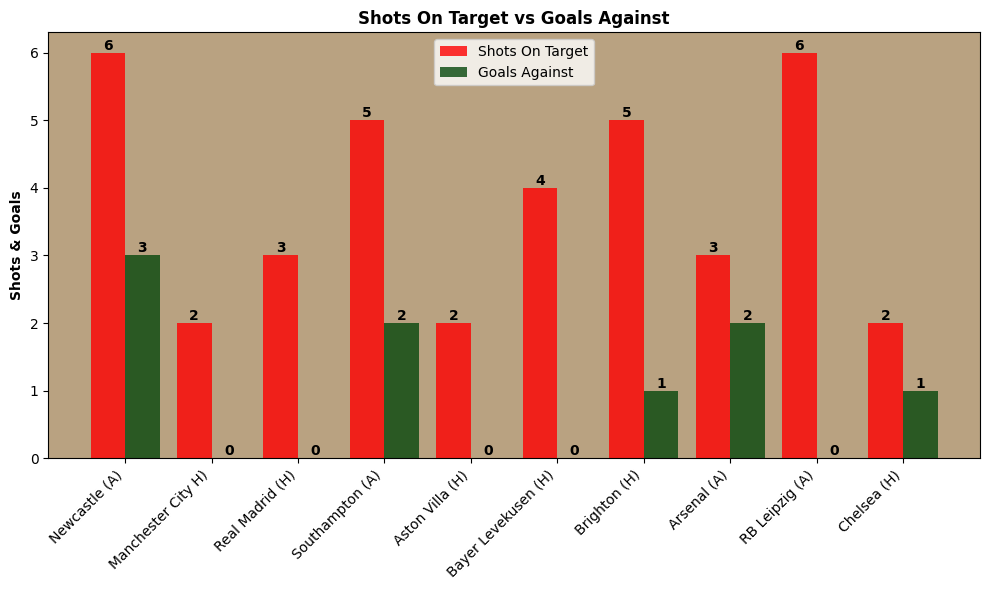

In [17]:
# Create Variables To Store Column Data 
fixtures = keeper_stats['Fixture']
shots_on_target = keeper_stats['SoTA']
goals_against = keeper_stats['GA']

# Create Variable To Store Numerical Positions For Fixtures. Use *np.arange()* To Even Space Array. Use Length Of Fixtures
x = np.arange(len(fixtures))

# Set Bar Width - (0 - 1)
bar_width = 0.4

# Create *fig* And *ax*- Plot *subplots* Set *figsize*
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Bar(s). (x (- / +) bar_width / *2* Moves The Bar Left / Right Of Center Using *bar_width*, Style (label, color, alpha))
bars1 = ax.bar(x - bar_width / 2, shots_on_target, width=bar_width, label="Shots On Target", color="red", alpha=0.8)
bars2 = ax.bar(x + bar_width / 2, goals_against, width=bar_width, label="Goals Against ", color="#06470c", alpha=0.8)

# Add Bar Labels
ax.bar_label(bars1, label_type='edge', fontsize=10, color='k', fontweight='bold')
ax.bar_label(bars2, label_type='edge', fontsize=10, color='k', fontweight='bold')

# Set x-label ticks As Variable Created - set_xticks(*variable*)
ax.set_xticks(x)

# Plot x-labels. (Call Varaible, Rotate, Move)
ax.set_xticklabels(fixtures, rotation=45, ha='right')

# Add y-labels & Title
ax.set_ylabel("Shots & Goals", fontweight="bold")
ax.set_title("Shots On Target vs Goals Against", fontweight="bold")

# Set Background Color (Hex Number)
ax.set_facecolor('#b9a281')

# Plot Legend
ax.legend()

# Adjust Spacing For Graph
plt.tight_layout()

# Display Graph
plt.show()

In [15]:
# Group Df By Column And Sum Variables
psxg = keeper_stats.groupby('Fixture')['PSxG'].sum()
# Show Df
psxg

Fixture
Arsenal (A)            1.7
Aston Villa (H)        0.6
Bayer Levekusen (H)    0.7
Brighton (H)           0.5
Chelsea (H)            0.9
Manchester City H)     0.9
Newcastle (A)          2.5
RB Leipzig (A)         1.2
Real Madrid (H)        1.8
Southampton (A)        1.7
Name: PSxG, dtype: float64

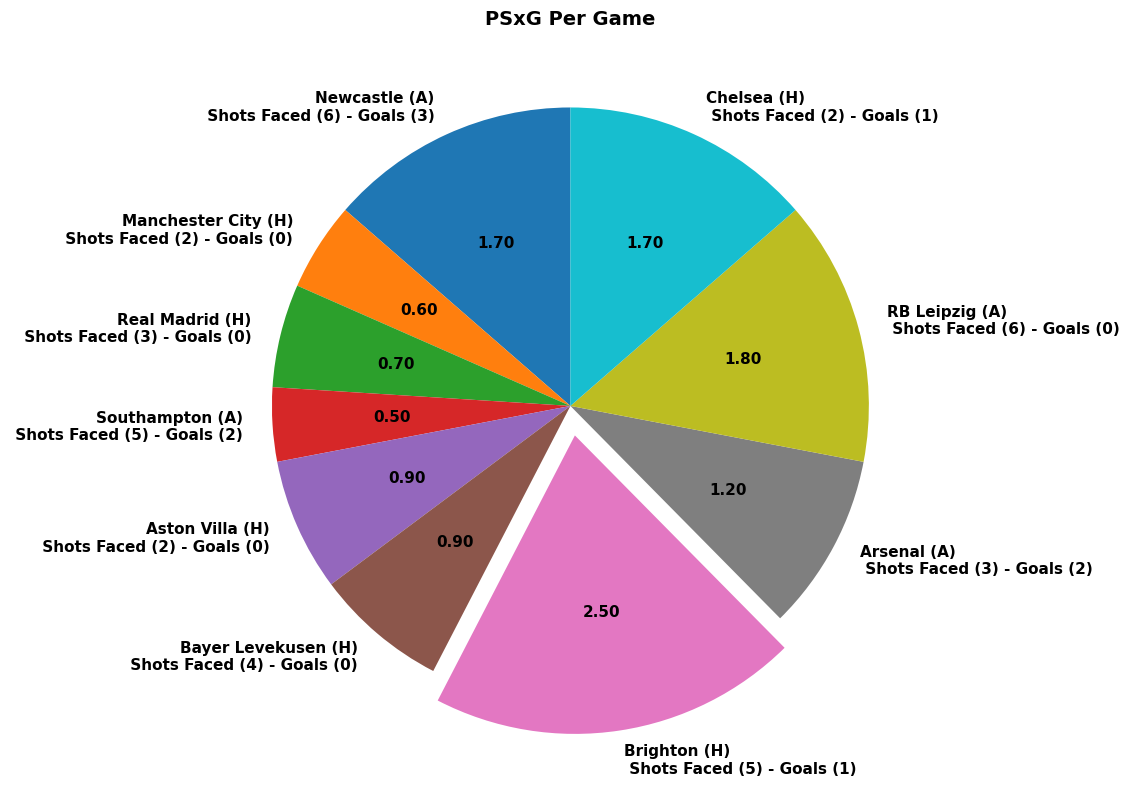

In [34]:
# List Of Fixtures 
fixtures = [
    "Newcastle (A)\n Shots Faced (6) - Goals (3)","Manchester City (H)\n Shots Faced (2) - Goals (0)",
    "Real Madrid (H)\n Shots Faced (3) - Goals (0)", "Southampton (A)\n Shots Faced (5) - Goals (2)",
    "Aston Villa (H)\n Shots Faced (2) - Goals (0)","Bayer Levekusen (H)\n Shots Faced (4) - Goals (0)",
    "Brighton (H)\n Shots Faced (5) - Goals (1)", "Arsenal (A)\n Shots Faced (3) - Goals (2)",
    "RB Leipzig (A)\n Shots Faced (6) - Goals (0)","Chelsea (H)\n Shots Faced (2) - Goals (1)"
]

# List Of Values
values = [1.7, 0.6, 0.7, 0.5, 0.9, 0.9, 2.5, 1.2, 1.8, 1.7]

# Create Pie Chart
# Plot Figure
# Call :
#  Wedges = Manipulate Wedge (explode)
#  Texts = (For)Loop Through To Modify Outside Labels (size, style, color)
#  Autotexts = (For)Loop Through To Modify Inside Labels (size, style, color)
# Plot Pie (Add Arguments/Parameters)
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    values,
    labels=fixtures,
    explode=[0,0,0,0,0,0,0.1,0,0,0],
    autopct=lambda p: f'{p * sum(values) / 100:.2f}',  
    startangle=90,
    textprops={'fontsize': 11, 'weight':'bold'}
)

# Plot Title & Show
plt.title("PSxG Per Game", fontsize=14, fontweight='bold')

# Adjust Spacing For Graph
plt.tight_layout()

# Display Figure
plt.show()

##### G.K Avg Length

In [22]:
# Show Df
keeper_stats

,Competiton,Fixture,SoTA,GA,Saves,Save %,PSxG,Launched %,Pass,Throw,Avg Length,G.K Avg Length
0,English Premier League,Newcastle (A),6,3,3,50.00%,2.5,27.30%,42,9,25.5,40.7
1,English Premier League,Manchester City H),2,0,2,100.00%,0.9,18.80%,45,5,31.6,0.0
2,Uefa Champions League,Real Madrid (H),3,0,2,100.00%,1.8,50.00%,28,3,21.7,19.4
3,English Premier League,Southampton (A),5,2,2,60.00%,1.7,28.60%,17,1,29.9,44.7
4,English Premier League,Aston Villa (H),2,0,2,100.00%,0.6,16.70%,28,3,25.7,62.0
5,Uefa Champions League,Bayer Levekusen (H),4,0,4,100.00%,0.7,36.40%,31,2,32.7,37.8
6,English Premier League,Brighton (H),5,1,4,80.00%,0.5,25.00%,27,4,25.4,0.0
7,English Premier League,Arsenal (A),3,2,1,33.30%,1.7,33.30%,41,3,37.0,35.0
8,Uefa Champions League,RB Leipzig (A),6,0,6,100.00%,1.2,36.40%,38,2,29.0,36.5
9,English Premier League,Chelsea (H),2,1,1,50.00%,0.9,20.00%,37,4,35.9,41.0


In [23]:
# Find Mean Of Values In Column
gk_mean = keeper_stats['G.K Avg Length'].mean()

# Show Df
gk_mean

np.float64(31.71)

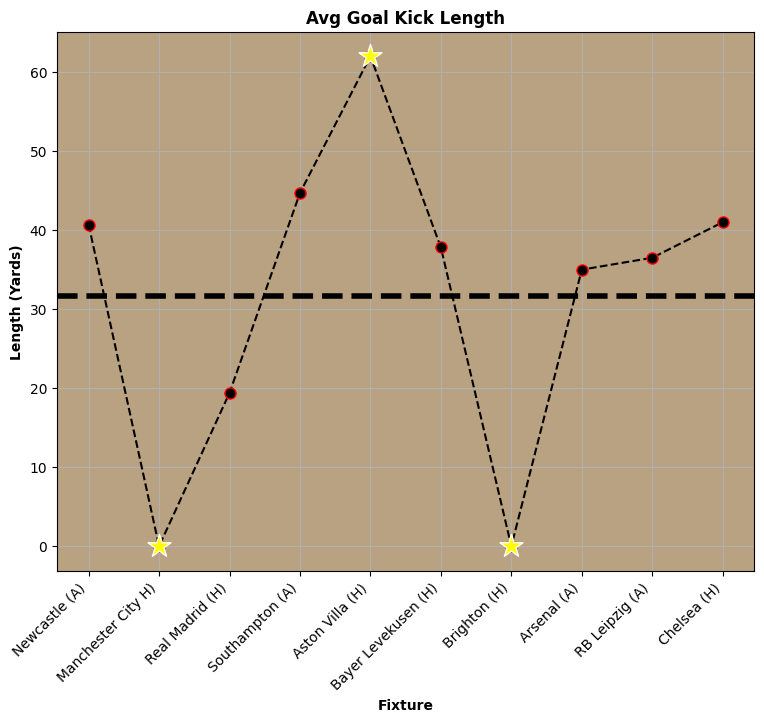

In [24]:
# Plot Figure And Figsize
plt.figure(figsize = (9, 7))

# Create And Plot Axes
ax = plt.axes()

# Create Variable That Holds All Fixtures
fixtures = keeper_stats['Fixture']

# Set The Backgroud Color
ax.set_facecolor('#b9a281')

# Plot xG Data Using Index, Then Column, Marker, Line And Color, Marker Size (ms), Marker Edge Color (mec)
plt.plot(keeper_stats['Fixture'], keeper_stats['G.K Avg Length'], 'o--k', ms=8, mec='r')

# Plot Avg Line
plt.axhline(y=gk_mean, color='black', linestyle='--', linewidth=4)

# Set Top Position
tp_mk = 4
plt.scatter(fixtures.iloc[tp_mk], keeper_stats['G.K Avg Length'].iloc[tp_mk],
           marker='*', s=300, color='yellow', edgecolor='w', zorder=5)

# Set Bottom Position
btm_mk1 = 1
plt.scatter(fixtures.iloc[btm_mk1], keeper_stats['G.K Avg Length'].iloc[btm_mk1],
           marker='*', s=300, color='yellow', edgecolor='w', zorder=2)

# Set Second Bottom Position
btm_mk2 = 6
plt.scatter(fixtures.iloc[btm_mk2], keeper_stats['G.K Avg Length'].iloc[btm_mk2],
           marker='*', s=300, color='yellow', edgecolor='w', zorder=2)

# Plot Labels And Fontweight
plt.xlabel('Fixture', fontweight='bold')
plt.ylabel('Length (Yards)', fontweight='bold')
plt.title('Avg Goal Kick Length', fontweight='bold')

# Plot x-ticks Using Index Column And Label With Fixture Variable, Rotate And Move 
plt.xticks(ticks=keeper_stats['Fixture'], labels=fixtures, rotation=45, ha='right')

# Plot Grid
plt.grid(True)

#### Pass, Throw

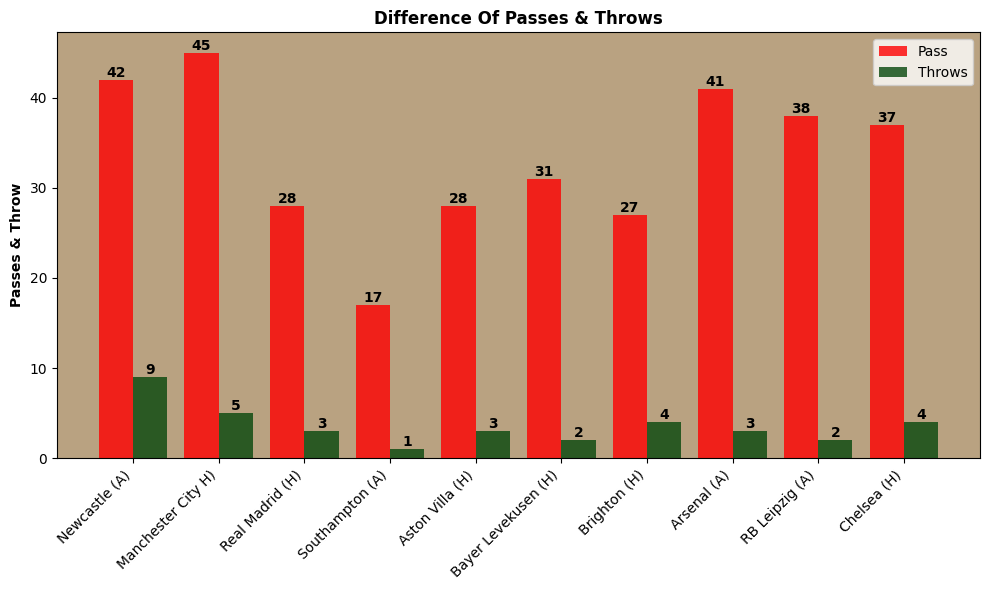

In [25]:
# Create Variables To Store Column Data 
fixtures = keeper_stats['Fixture']
pass_att = keeper_stats['Pass']
throw = keeper_stats['Throw']

# Create Variable To Store Numerical Positions For Fixtures. Use *np.arange()* To Even Space Array. Get *len* Of Fixtures
x = np.arange(len(fixtures))  

# Set Bar Width
bar_width = 0.4

# Create *fig* And *ax*- Plot *subplots* Set *figsize*
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Bar(s). (x (- / +) bar_width / *2* Moves The Bar Left / Right Of Center Using *bar_width*, Style (label, color, alpha))
bars1 = ax.bar(x - bar_width / 2, pass_att, width=bar_width, label="Pass", color="red", alpha=0.8)
bars2 = ax.bar(x + bar_width / 2, throw, width=bar_width, label="Throws", color="#06470c", alpha=0.8)

# Add Bar Labels
ax.bar_label(bars1, label_type='edge', fontsize=10, color='k', fontweight='bold')
ax.bar_label(bars2, label_type='edge', fontsize=10, color='k', fontweight='bold')

# Set x-label ticks As Variable Created - set_xticks(*variable*)
ax.set_xticks(x)

# Plot x-labels. (Call Varaible, Rotate, Move)
ax.set_xticklabels(fixtures, rotation=45, ha='right')

# Add y-Label & Title
ax.set_ylabel("Passes & Throw", fontweight="bold")
ax.set_title("Difference Of Passes & Throws", fontweight="bold")

# Set Background Color 
ax.set_facecolor('#b9a281')

# Add legend
ax.legend()

# Adjust Spacing For Graph
plt.tight_layout()

# Display Figure 
plt.show()

#### Distribution Avg Length

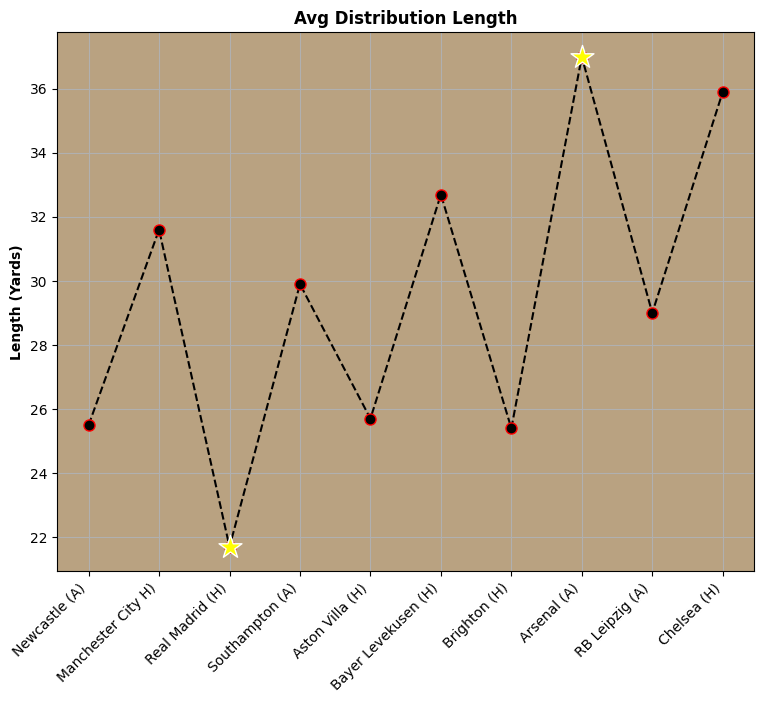

In [33]:
# Plot Figure And Figsize
plt.figure(figsize = (9, 7))

# Create And Plot Axes
ax = plt.axes()

# Create Variable That Holds All Fixtures
fixtures = keeper_stats['Fixture']

# Set The Background Color
ax.set_facecolor('#b9a281')

# Plot xG Data Using Index, Then Column, Marker, Line And Color, Marker Size (ms), Marker Egde Color (mec)
plt.plot(keeper_stats['Fixture'], keeper_stats['Avg Length'], 'o--k', ms=8, mec='r')

# Set Marker For Top Player
top_mark = 7
plt.scatter(fixtures.iloc[top_mark], keeper_stats['Avg Length'].iloc[top_mark],
           marker='*', s=300, color='yellow', edgecolor='w', zorder=7)

# Set Marker For Bottom Player
bottom_mark = 2
plt.scatter(fixtures.iloc[bottom_mark], keeper_stats['Avg Length'].iloc[bottom_mark],
           marker='*', s=300, color='yellow', edgecolor='w', zorder=9)

# Plot Labels And Fontweight
plt.ylabel('Length (Yards)', fontweight='bold')
plt.title('Avg Distribution Length', fontweight='bold')

# Plot x-ticks Using Index Column And Label With Fixture Variable, Rotate And Move 
plt.xticks(ticks=keeper_stats['Fixture'], labels=fixtures, rotation=45, ha='right')

# Print Grid Lines. Show Specific Line (axis), Color, Line Width
plt.grid(True)